In [18]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from importlib.machinery import SourceFileLoader

import shap
from baal.modelwrapper import ModelWrapper

import os, sys, torch
from pathlib import Path
from importlib.machinery import SourceFileLoader


In [19]:
MODEL_DIR = Path("./").resolve()
const_path  = MODEL_DIR / "constants.py"
fusion_path = MODEL_DIR / "UFNet_withhold_predictions.py"

# load constants first
consts = SourceFileLoader("constants", str(const_path)).load_module()

# make sure bare `import constants` works inside fusion module
sys.modules["constants"] = consts
sys.path.insert(0, str(MODEL_DIR))   # so Python can also find local imports if any

# now load fusion
fusion_mod = SourceFileLoader("UFNet_withhold_predictions", str(fusion_path)).load_module()

# use as before
BASE_DIR          = consts.BASE_DIR
MODEL_BASE_PATH   = consts.MODEL_BASE_PATH
MODEL_CONFIG_PATH = consts.MODEL_CONFIG_PATH
MODEL_PATH        = consts.MODEL_PATH
MODEL_SUBSETS     = consts.MODEL_SUBSETS

HybridFusion = fusion_mod.HybridFusionNetworkWithUncertainty
ShallowANN   = fusion_mod.ShallowANN
ANN          = fusion_mod.ANN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
torch.set_grad_enabled(False)


Number of patients in the dev and test set: 267, 267
Using device: cuda


In [20]:
# ---------- Load fusion config & choose modalities ----------
with open(MODEL_CONFIG_PATH, "r") as f:
    cfg = json.load(f)

selected_tags = MODEL_SUBSETS[cfg["model_subset_choice"]]
fusion_mod.NUM_MODELS = len(selected_tags)
NUM_MODELS = fusion_mod.NUM_MODELS
print(f"[INFO] Modalities (order): {selected_tags}  (NUM_MODELS={NUM_MODELS})")

def _tag2name(tag: str) -> str:
    t = tag.lower()
    if "finger" in t: return "finger"
    if "fox" in t or "speech" in t: return "speech"
    if "facial" in t or "smile" in t: return "smile"
    return tag


[INFO] Modalities (order): ['finger_model_both_hand_fusion_baal', 'fox_model_best_auroc_baal', 'facial_expression_smile_best_auroc_baal']  (NUM_MODELS=3)


In [21]:
# ---------- Build fusion dataframe exactly like training ----------
def build_fusion_df():
    model_paths = []
    for MODEL_TAG in selected_tags:
        model_paths.append({
            "TAG": MODEL_TAG,
            "PREDICTOR_CONFIG": os.path.join(MODEL_BASE_PATH, MODEL_TAG, "predictive_model", "model_config.json"),
            "PREDICTOR_MODEL":  os.path.join(MODEL_BASE_PATH, MODEL_TAG, "predictive_model", "model.pth"),
            "SCALER_PKL":       os.path.join(MODEL_BASE_PATH, MODEL_TAG, "scaler", "scaler.pkl"),
            "SCALER_PTH":       os.path.join(MODEL_BASE_PATH, MODEL_TAG, "scaler", "scaler.pth"),
        })

    merged = None
    for i, paths in enumerate(model_paths):
        with open(paths["PREDICTOR_CONFIG"], "r") as f:
            pc = json.load(f)
        drop_corr = (pc.get("drop_correlated", "yes") == "yes")
        corr_thr  = pc.get("corr_thr", 0.85)

        if "finger_model" in paths["TAG"]:
            fr, lr, idr, _, rid_r = fusion_mod.load_finger_data(hand="right", drop_correlated=drop_corr, corr_thr=corr_thr)
            fl, ll, idl, _, rid_l = fusion_mod.load_finger_data(hand="left",  drop_correlated=drop_corr, corr_thr=corr_thr)
            dfr  = pd.DataFrame({"features_right": list(fr), "id_right": idr, "row_id": rid_r, "label_right": lr})
            dfl  = pd.DataFrame({"features_left":  list(fl), "id_left":  idl, "row_id": rid_l, "label_left":  ll})
            both = dfr.merge(dfl, on="row_id", how="inner") \
                      .drop(columns=["label_left","id_left"]) \
                      .rename(columns={"label_right":"label", "id_right":"id"})
            both["features"] = both.apply(fusion_mod.concat_finger_features, axis=1)
            features = np.stack(both["features"].to_numpy())
            labels   = both["label"].to_numpy()
            ids      = both["id"].to_numpy()
            row_ids  = both["row_id"].to_numpy()
        elif "fox_model" in paths["TAG"]:
            features, labels, ids, _, row_ids = fusion_mod.load_qbf_data(drop_correlated=drop_corr, corr_thr=corr_thr)
        elif "facial_expression_smile" in paths["TAG"]:
            features, labels, ids, _, row_ids = fusion_mod.load_smile_data(drop_correlated=drop_corr, corr_thr=corr_thr)
        else:
            raise RuntimeError(f"Unknown model tag: {paths['TAG']}")

        scaler = None
        if pc.get("use_feature_scaling","no") == "yes":
            if os.path.exists(paths["SCALER_PKL"]):
                scaler = pickle.load(open(paths["SCALER_PKL"], "rb"))
            elif os.path.exists(paths["SCALER_PTH"]):
                scaler = pickle.load(open(paths["SCALER_PTH"], "rb"))
            if scaler is not None:
                features = scaler.transform(features)

        block = pd.DataFrame({
            f"features_{i}": list(features),
            f"label_{i}":    labels,
            f"id_{i}":       ids,
            "row_id":        row_ids
        })
        if merged is None:
            merged = block
        else:
            merged = merged.merge(block, on="row_id", how="inner") \
                           .drop(columns=[f"label_{i}", f"id_{i}"])

    df = merged.rename(columns={"label_0":"label","id_0":"id"})
    print(f"[INFO] Fusion df: {df.shape}, columns={list(df.columns)}")
    return df, model_paths

fusion_df, model_paths = build_fusion_df()
feature_shapes = [len(fusion_df.iloc[0][f"features_{i}"]) for i in range(NUM_MODELS)]
modality_names = [_tag2name(t) for t in selected_tags]


Number of features: 116
Number of features: 116
Number of features: 1015
Number of features: 42
[INFO] Fusion df: (806, 6), columns=['features_0', 'label', 'id', 'row_id', 'features_1', 'features_2']


In [22]:
# ---------- Load frozen unimodal predictors exactly like training ----------
def load_unimodal_models():
    models = []
    for i, paths in enumerate(model_paths):
        with open(paths["PREDICTOR_CONFIG"], "r") as f:
            pc = json.load(f)
        drop_prob  = pc["dropout_prob"]
        model_type = pc.get("model","ANN")
        if model_type == "ShallowANN":
            mdl = ShallowANN(feature_shapes[i], drop_prob=drop_prob)
            mdl.load_state_dict(torch.load(paths["PREDICTOR_MODEL"], map_location=DEVICE))
            mdl = mdl.to(DEVICE).eval()
            mdl.fc.weight.requires_grad = False
            mdl.fc.bias.requires_grad = False
        else:
            mdl = ANN(feature_shapes[i], drop_prob=drop_prob)
            mdl.load_state_dict(torch.load(paths["PREDICTOR_MODEL"], map_location=DEVICE))
            mdl = mdl.to(DEVICE).eval()
            mdl.fc1.weight.requires_grad = False
            mdl.fc1.bias.requires_grad   = False
            mdl.fc2.weight.requires_grad = False
            mdl.fc2.bias.requires_grad   = False
        models.append(mdl)
    print("[INFO] Unimodal predictors loaded.")
    return models

unimodal_models = load_unimodal_models()

[INFO] Unimodal predictors loaded.


In [23]:
# ---------- Compute unimodal MC-dropout means/vars ----------
def predict_unimodal_scores_and_vars(df, num_trials):
    wrappers = [ModelWrapper(m, nn.BCELoss()) for m in unimodal_models]
    scores = {}
    vars_  = {}
    X_mods = [np.stack(df[f"features_{i}"].to_numpy()) for i in range(NUM_MODELS)]
    for i, name in enumerate(modality_names):
        X = torch.from_numpy(X_mods[i]).float().to(DEVICE)
        y_multi = wrappers[i].predict_on_batch(X, iterations=num_trials)  # [B, T]
        y_multi = y_multi.detach().cpu().numpy() if hasattr(y_multi, "detach") else np.asarray(y_multi)
        scores[name] = y_multi.mean(axis=-1).astype(np.float32)  # [B]
        vars_[name]  = y_multi.std(axis=-1).astype(np.float32)   # [B]
        print(f"[INFO] {name}: computed {len(scores[name])} scores/vars (T={num_trials}).")
    return scores, vars_

num_trials = int(cfg.get("num_trials", 30))
unimodal_scores, unimodal_vars = predict_unimodal_scores_and_vars(fusion_df, num_trials)


[INFO] finger: computed 806 scores/vars (T=30).
[INFO] speech: computed 806 scores/vars (T=30).
[INFO] smile: computed 806 scores/vars (T=30).


In [24]:
# ---------- Build flat matrix (features + preds + vars) ----------
def _to_1d(x):
    a = np.asarray(x)
    if a.ndim == 1: return a
    a = np.squeeze(a)
    if a.ndim == 1: return a
    b_ax = int(np.argmax(a.shape))  # keep batch axis, average others
    axes = tuple(ax for ax in range(a.ndim) if ax != b_ax)
    return a.mean(axis=axes)

for name in modality_names:
    unimodal_scores[name] = _to_1d(unimodal_scores[name]).astype(np.float32)
    unimodal_vars[name]   = _to_1d(unimodal_vars[name]).astype(np.float32)

feat_slices = []
start = 0
for d in feature_shapes:
    feat_slices.append(slice(start, start + d))
    start += d
pred_slice = slice(start, start + len(modality_names)); start += len(modality_names)
var_slice  = slice(start, start + len(modality_names)); start += len(modality_names)
TOTAL_D    = start

def build_flat_matrix_features_preds_vars(df):
    feats_per_mod  = [np.stack(df[f"features_{i}"].to_numpy()).astype(np.float32)
                      for i in range(len(modality_names))]
    features_block = np.concatenate(feats_per_mod, axis=1)  # [B, sum(d_i)]
    preds_block = np.column_stack([unimodal_scores[name] for name in modality_names]).astype(np.float32)  # [B, K]
    vars_block  = np.column_stack([unimodal_vars[name]   for name in modality_names]).astype(np.float32)  # [B, K]
    B = features_block.shape[0]
    assert preds_block.shape == (B, len(modality_names))
    assert vars_block.shape  == (B, len(modality_names))
    return np.concatenate([features_block, preds_block, vars_block], axis=1)

X_all = build_flat_matrix_features_preds_vars(fusion_df)
y_all = fusion_df["label"].astype(int).to_numpy()

feature_names = []
for i, name in enumerate(modality_names):
    feature_names += [f"{name}_{j}" for j in range(feature_shapes[i])]
feature_names += [f"pred_{name}" for name in modality_names]
feature_names += [f"var_{name}"  for name in modality_names]

print(f"[INFO] X_all: {X_all.shape}  (features={sum(feature_shapes)}, preds+vars={2*len(modality_names)}, TOTAL_D={TOTAL_D})")


[INFO] X_all: (806, 1295)  (features=1289, preds+vars=6, TOTAL_D=1295)


In [25]:
# ---------- Load fusion model & make it deterministic ----------
fusion_model = HybridFusion(feature_shapes, cfg).to(DEVICE)
fusion_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
fusion_model.eval()

def disable_mc_dropout(module: torch.nn.Module):
    for m in module.modules():
        if m.__class__.__module__.startswith("baal") and m.__class__.__name__.lower().endswith("dropout"):
            if hasattr(m, "p"): m.p = 0.0
            m.training = False
        if isinstance(m, torch.nn.Dropout):
            m.p = 0.0
            m.training = False

disable_mc_dropout(fusion_model)

In [26]:
import numpy as np
import torch
import torch.nn as nn

class FusionWrapper(nn.Module):
    """
    X layout (src order):
      [ features_0 | ... | features_{K-1} | preds (K) | vars (K) ]

    Calls the model with ONE arg:
      (features_list, preds_list, vars_list)
      - features_list : list of [N, d_i] tensors (model order)
      - preds_list    : list of [N] tensors (model order)
      - vars_list     : list of [N] tensors (model order)
    """
    def __init__(self,
                 fusion_model,
                 feat_slices,            # per-modality feature slices in X (src order)
                 pred_slice,             # slice for preds in X
                 var_slice,              # slice for vars  in X
                 src_modality_names,     # e.g. ["finger","speech","smile"] in X order
                 model_selected_tags,    # tags used to build the model (model order)
                 device,
                 default_pred: float = 0.5,
                 default_var: float = 0.0):
        super().__init__()
        self.m = fusion_model.eval()
        self.device = device
        self.feat_slices = list(feat_slices)
        self.pred_slice  = pred_slice
        self.var_slice   = var_slice
        self.src_names   = list(src_modality_names)
        self.default_pred = float(default_pred)
        self.default_var  = float(default_var)

        def _tag2name(tag: str) -> str:
            t = str(tag).lower()
            if "finger" in t: return "finger"
            if "fox" in t or "speech" in t: return "speech"
            if "facial" in t or "smile"  in t: return "smile"
            return t

        # Model’s expected modality order
        self.model_names = [_tag2name(t) for t in model_selected_tags]

        # Map: model order -> indices in X (src order)
        self.src_idx_for_model = [self.src_names.index(nm) for nm in self.model_names]

        # Feature slices reordered to model order
        self.ordered_feat_slices = [self.feat_slices[i] for i in self.src_idx_for_model]

    def forward(self, x_np):
        # Accept (D,) or (N,D); return (N,)
        x = torch.from_numpy(np.asarray(x_np)).float()
        if x.ndim == 1:
            x = x.unsqueeze(0)
        x = x.to(self.device)
        N = x.shape[0]
        K = len(self.ordered_feat_slices)

        # 1) features_list: list of [N, d_i] (model order)
        features_list = [x[:, sl] for sl in self.ordered_feat_slices]

        # 2) preds_list: list of [N] (model order)
        if self.pred_slice is None:
            preds_mat = torch.full((N, K), self.default_pred, dtype=x.dtype, device=x.device)
        else:
            preds_src = x[:, self.pred_slice]            # [N, K_src] or [N]
            if preds_src.ndim == 1:
                preds_src = preds_src.view(N, -1)
            preds_mat = preds_src[:, self.src_idx_for_model]   # [N, K] model order
        preds_list = [preds_mat[:, i].reshape(N).contiguous() for i in range(K)]

        # 3) vars_list: list of [N] (model order)
        if self.var_slice is None:
            vars_mat = torch.full((N, K), self.default_var, dtype=x.dtype, device=x.device)
        else:
            vars_src = x[:, self.var_slice]              # [N, K_src] or [N]
            if vars_src.ndim == 1:
                vars_src = vars_src.view(N, -1)
            vars_mat = vars_src[:, self.src_idx_for_model]     # [N, K] model order
        vars_list = [vars_mat[:, i].reshape(N).contiguous() for i in range(K)]

        # 4) Single 3-tuple call → model will torch.stack(...).transpose(0,1) internally
        out = self.m((features_list, preds_list, vars_list))
        return out.reshape(-1).detach().cpu().numpy()


In [27]:
wrapped = FusionWrapper(
    fusion_model=fusion_model,
    feat_slices=feat_slices,
    pred_slice=pred_slice,
    var_slice=var_slice,
    src_modality_names=modality_names,   # X order
    model_selected_tags=selected_tags,   # model's expected order
    device=DEVICE
).eval()

In [33]:

# ====================== SHAP: Train background, Test evaluation ======================

test_ids = [ln.strip() for ln in open(BASE_DIR + "data/test_set_participants_full_cohort.txt")]
assert "id" in fusion_df.columns, "fusion_df must have an 'id' column."

# ---- 1) Build row masks: test = ids in test_ids; train = not in test ----
# (Per-row SHAP. If you want 1 row per participant, dedupe here before masking.)
id_series = fusion_df["id"]
test_mask  = id_series.isin(test_ids).to_numpy()
train_mask = ~test_mask

idx_test  = np.flatnonzero(test_mask)
idx_train = np.flatnonzero(train_mask)

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

print(f"[INFO] Rows — train: {len(X_train)}, test: {len(X_test)}  (features D={X_all.shape[1]})")



[INFO] Rows — train: 646, test: 160  (features D=1295)


In [ ]:

# # ---- 2) Summarize TRAIN distribution for SHAP background ----
# # Smaller k is usually more stable/faster for KernelExplainer
# k_bg = min(50, len(X_train))
# X_bg = shap.kmeans(X_train, k_bg)

# bg_shape = X_bg.data.shape if hasattr(X_bg, "data") else np.asarray(X_bg).shape
# print(f"[INFO] Background (train k-means): k={k_bg}, shape={bg_shape}")


# # ---- 3) Safe prediction wrappers ----
# # Preferred: explain logits with identity link
# # Fallback: explain clipped probabilities with logit link

# use_logits = hasattr(wrapped, "forward_logits")

# def model_fn_logit(A):
#     z = wrapped.forward_logits(A)
#     z = np.asarray(z).reshape(-1)
#     z = np.nan_to_num(z, nan=0.0, posinf=20.0, neginf=-20.0)
#     return z

# def model_fn_prob_clipped(A):
#     p = wrapped.forward(A)
#     p = np.asarray(p).reshape(-1)
#     p = np.nan_to_num(p, nan=0.5, posinf=1.0, neginf=0.0)
#     eps = 1e-6
#     p = np.clip(p, eps, 1 - eps)
#     return p


# # ---- 4) Sanity check outputs ----
# try:
#     if use_logits:
#         out_check = model_fn_logit(X_test[:10])
#         print("[INFO] Using logits + identity link")
#         print("[INFO] Logit range on first 10 test rows:",
#               float(np.min(out_check)), float(np.max(out_check)))
#     else:
#         out_check = model_fn_prob_clipped(X_test[:10])
#         print("[INFO] Using clipped probabilities + logit link")
#         print("[INFO] Probability range on first 10 test rows:",
#               float(np.min(out_check)), float(np.max(out_check)))
# except Exception as e:
#     print("[WARN] Initial output check failed:", e)
#     print("[WARN] Falling back to clipped probabilities + logit link")
#     use_logits = False
#     out_check = model_fn_prob_clipped(X_test[:10])
#     print("[INFO] Probability range on first 10 test rows:",
#           float(np.min(out_check)), float(np.max(out_check)))


# # ---- 5) Build explainer ----
# nsamp = 1500
# l1_reg = "num_features(64)"

# if use_logits:
#     expl = shap.KernelExplainer(model_fn_logit, X_bg, link="identity")
# else:
#     expl = shap.KernelExplainer(model_fn_prob_clipped, X_bg, link="logit")

# print(f"[INFO] Explaining TEST: nsamples={nsamp}, l1_reg={l1_reg}")


# # ---- 6) Run SHAP, with fallback to SamplingExplainer ----
# try:
#     shap_vals_test = expl.shap_values(X_test, nsamples=nsamp, l1_reg=l1_reg)
#     expected_value_test = expl.expected_value
# except Exception as e:
#     print("[WARN] KernelExplainer failed; falling back to SamplingExplainer:", e)

#     if use_logits:
#         expl = shap.SamplingExplainer(model_fn_logit, X_bg)
#     else:
#         expl = shap.SamplingExplainer(model_fn_prob_clipped, X_bg)

#     shap_vals_test = expl.shap_values(X_test, nsamples=nsamp)
#     expected_value_test = expl.expected_value


# # ---- 7) Cleanup ----
# shap_vals_test = np.asarray(shap_vals_test)
# shap_vals_test = np.nan_to_num(shap_vals_test, nan=0.0, posinf=0.0, neginf=0.0)

# print("[INFO] Test SHAP done:", shap_vals_test.shape, "expected_value:", expected_value_test)
# print("[INFO] Any NaN in SHAP?", np.isnan(shap_vals_test).any())
# print("[INFO] Any Inf in SHAP?", np.isinf(shap_vals_test).any())



[INFO] Background (train k-means): k=50, shape=(50, 1295)
[INFO] Using clipped probabilities + logit link
[INFO] Probability range on first 10 test rows: 9.999999974752427e-07 0.9999964237213135
[INFO] Explaining TEST: nsamples=1500, l1_reg=num_features(64)


100%|██████████| 160/160 [03:41<00:00,  1.38s/it]

[INFO] Test SHAP done: (160, 1295) expected_value: -1.5660996684459765
[INFO] Any NaN in SHAP? False
[INFO] Any Inf in SHAP? False


In [51]:
# # ---- 2) Background from TRAIN distribution (smaller summary) ----
# k_bg = min(50, len(X_train))
# X_bg = shap.kmeans(X_train, k_bg)

# print(f"[INFO] Background k={k_bg}")
# print("[INFO] Background shape:", X_bg.data.shape if hasattr(X_bg, "data") else np.asarray(X_bg).shape)

# # ---- 3) Stable wrapper ----
# def f_prob_clipped(A):
#     p = wrapped.forward(A)
#     p = np.asarray(p).reshape(-1)
#     eps = 1e-6
#     return np.clip(p, eps, 1 - eps)

# expl = shap.KernelExplainer(f_prob_clipped, X_bg, link="logit")

# nsamp = 1500
# l1_reg = "num_features(64)"

# shap_vals_test = expl.shap_values(X_test, nsamples=nsamp, l1_reg=l1_reg)
# expected_value_test = expl.expected_value
# shap_vals_test = np.asarray(shap_vals_test)
# print("[INFO] Test SHAP done:", shap_vals_test.shape, "expected_value:", expected_value_test)

In [14]:
# # ---- 6) Save everything AS-IS via pickle ----
# OUT_DIR = os.path.join(BASE_DIR, "shap_outputs")
# os.makedirs(OUT_DIR, exist_ok=True)
# dump_path = os.path.join(OUT_DIR, "shap_values_full_dataset.pkl")

# with open(dump_path, "wb") as f:
#     pickle.dump(
#         # store exactly what you'd want to reload
#         (shap_vals_test, idx_test, expected_value_test, feature_names, X_test, nsamp, k_bg, l1_reg),
#         f,
#         protocol=pickle.HIGHEST_PROTOCOL
#     )

# print(f"[INFO] Pickled test SHAP (train background) to {dump_path}")

In [37]:
import pickle, os
OUT_DIR = os.path.join("shap_outputs")
dump_path = os.path.join(BASE_DIR,OUT_DIR,"shap_values_full_dataset.pkl")
with open(dump_path, "rb") as f:
    shap_vals_test, idx_test, expected_value_test, feature_names, X_test, nsamp, k_bg, l1_reg = pickle.load(f)



In [30]:
finger_feature_names = [
    "Wrist X Med (R)",
    "Wrist X IQR (R)",
    "Wrist X Mean (R)",
    "Wrist X Min (R)",
    "Wrist X Max (R)",
    "Wrist X Std (R)",
    "Wrist Y Med (R)",
    "Wrist Y IQR (R)",
    "Wrist Y Mean (R)",
    "Wrist Y Min (R)",
    "Wrist Y Max (R)",
    "Wrist Y Std (R)",
    "Wrist Dist Med (R)",
    "Wrist Dist IQR (R)",
    "Wrist Dist Mean (R)",
    "Wrist Dist Min (R)",
    "Wrist Dist Max (R)",
    "Wrist Dist Std (R)",
    "Aperiodicity (D) (R)",
    "Aperiodicity (T) (R)",
    "Interval Ent (D) (R)",
    "Interval Ent (T) (R)",
    "Interval VarNorm (D) (R)",
    "Interval VarNorm (T) (R)",
    "Interruptions (D) (R)",
    "Interruptions (T) (R)",
    "Freeze Count (D) (R)",
    "Freeze Count (T) (R)",
    "Max Freeze Dur (D) (R)",
    "Max Freeze Dur (T) (R)",
    "Interval Med (D) (R)",
    "Interval IQR (D) (R)",
    "Interval Mean (D) (R)",
    "Interval Min (D) (R)",
    "Interval Max (D) (R)",
    "Interval Std (D) (R)",
    "Interval Med (T) (R)",
    "Interval IQR (T) (R)",
    "Interval Mean (T) (R)",
    "Interval Min (T) (R)",
    "Interval Max (T) (R)",
    "Interval Std (T) (R)",
    "Interval Ent (D) (R)",
    "Interval Ent (T) (R)",
    "Freq Med (D) (R)",
    "Freq IQR (D) (R)",
    "Freq Mean (D) (R)",
    "Freq Min (D) (R)",
    "Freq Max (D) (R)",
    "Freq Std (D) (R)",
    "Freq Med (T) (R)",
    "Freq IQR (T) (R)",
    "Freq Mean (T) (R)",
    "Freq Min (T) (R)",
    "Freq Max (T) (R)",
    "Freq Std (T) (R)",
    "Freq Fitness R2 (D) (R)",
    "Freq Slope (D) (R)",
    "Freq Fitness R2 (T) (R)",
    "Freq Slope (T) (R)",
    "Freq Fit Deg (D) (R)",
    "Freq Fit Deg (T) (R)",
    "Amp Med (D) (R)",
    "Amp IQR (D) (R)",
    "Amp Mean (D) (R)",
    "Amp Min (D) (R)",
    "Amp Max (D) (R)",
    "Amp Std (D) (R)",
    "Amp Ent (D) (R)",
    "Amp Med (T) (R)",
    "Amp IQR (T) (R)",
    "Amp Mean (T) (R)",
    "Amp Min (T) (R)",
    "Amp Max (T) (R)",
    "Amp Std (T) (R)",
    "Amp Ent (T) (R)",
    "Amp Decay R2 (D) (R)",
    "Amp Decay Slope (D) (R)",
    "Amp Decay End/Mean (D) (R)",
    "Amp Decay Deg (D) (R)",
    "Amp Decay Half-Ratio (D) (R)",
    "Amp Decay R2 (T) (R)",
    "Amp Decay Slope (T) (R)",
    "Amp Decay End/Mean (T) (R)",
    "Amp Decay Deg (T) (R)",
    "Amp Decay Half-Ratio (T) (R)",
    "Peak Count (T) (R)",
    "Peak Count (D) (R)",
    "Norm Interrupts (D) (R)",
    "Norm Freezes (D) (R)",
    "Norm Interrupts (T) (R)",
    "Norm Freezes (T) (R)",
    "Speed Med (D) (R)",
    "Speed IQR (D) (R)",
    "Speed Mean (D) (R)",
    "Speed Min (D) (R)",
    "Speed Max (D) (R)",
    "Speed Std (D) (R)",
    "Speed Med (T) (R)",
    "Speed IQR (T) (R)",
    "Speed Mean (T) (R)",
    "Speed Min (T) (R)",
    "Speed Max (T) (R)",
    "Speed Std (T) (R)",
    "Accel Med (D) (R)",
    "Accel IQR (D) (R)",
    "Accel Mean (D) (R)",
    "Accel Min (D) (R)",
    "Accel Max (D) (R)",
    "Accel Std (D) (R)",
    "Accel Med (T) (R)",
    "Accel IQR (T) (R)",
    "Accel Mean (T) (R)",
    "Accel Min (T) (R)",
    "Accel Max (T) (R)",
    "Accel Std (T) (R)",
    # --- Left Hand Tapping ---
    "Wrist X Med (L)",
    "Wrist X IQR (L)",
    "Wrist X Mean (L)",
    "Wrist X Min (L)",
    "Wrist X Max (L)",
    "Wrist X Std (L)",
    "Wrist Y Med (L)",
    "Wrist Y IQR (L)",
    "Wrist Y Mean (L)",
    "Wrist Y Min (L)",
    "Wrist Y Max (L)",
    "Wrist Y Std (L)",
    "Wrist Dist Med (L)",
    "Wrist Dist IQR (L)",
    "Wrist Dist Mean (L)",
    "Wrist Dist Min (L)",
    "Wrist Dist Max (L)",
    "Wrist Dist Std (L)",
    "Aperiodicity (D) (L)",
    "Aperiodicity (T) (L)",
    "Interval Ent (D) (L)",
    "Interval Ent (T) (L)",
    "Interval VarNorm (D) (L)",
    "Interval VarNorm (T) (L)",
    "Interruptions (D) (L)",
    "Interruptions (T) (L)",
    "Freeze Count (D) (L)",
    "Freeze Count (T) (L)",
    "Max Freeze Dur (D) (L)",
    "Max Freeze Dur (T) (L)",
    "Interval Med (D) (L)",
    "Interval IQR (D) (L)",
    "Interval Mean (D) (L)",
    "Interval Min (D) (L)",
    "Interval Max (D) (L)",
    "Interval Std (D) (L)",
    "Interval Med (T) (L)",
    "Interval IQR (T) (L)",
    "Interval Mean (T) (L)",
    "Interval Min (T) (L)",
    "Interval Max (T) (L)",
    "Interval Std (T) (L)",
    "Interval Ent (D) (L)",
    "Interval Ent (T) (L)",
    "Freq Med (D) (L)",
    "Freq IQR (D) (L)",
    "Freq Mean (D) (L)",
    "Freq Min (D) (L)",
    "Freq Max (D) (L)",
    "Freq Std (D) (L)",
    "Freq Med (T) (L)",
    "Freq IQR (T) (L)",
    "Freq Mean (T) (L)",
    "Freq Min (T) (L)",
    "Freq Max (T) (L)",
    "Freq Std (T) (L)",
    "Freq Fitness R2 (D) (L)",
    "Freq Slope (D) (L)",
    "Freq Fitness R2 (T) (L)",
    "Freq Slope (T) (L)",
    "Freq Fit Deg (D) (L)",
    "Freq Fit Deg (T) (L)",
    "Amp Med (D) (L)",
    "Amp IQR (D) (L)",
    "Amp Mean (D) (L)",
    "Amp Min (D) (L)",
    "Amp Max (D) (L)",
    "Amp Std (D) (L)",
    "Amp Ent (D) (L)",
    "Amp Med (T) (L)",
    "Amp IQR (T) (L)",
    "Amp Mean (T) (L)",
    "Amp Min (T) (L)",
    "Amp Max (T) (L)",
    "Amp Std (T) (L)",
    "Amp Ent (T) (L)",
    "Amp Decay R2 (D) (L)",
    "Amp Decay Slope (D) (L)",
    "Amp Decay End/Mean (D) (L)",
    "Amp Decay Deg (D) (L)",
    "Amp Decay Half-Ratio (D) (L)",
    "Amp Decay R2 (T) (L)",
    "Amp Decay Slope (T) (L)",
    "Amp Decay End/Mean (T) (L)",
    "Amp Decay Deg (T) (L)",
    "Amp Decay Half-Ratio (T) (L)",
    "Peak Count (T) (L)",
    "Peak Count (D) (L)",
    "Norm Interrupts (D) (L)",
    "Norm Freezes (D) (L)",
    "Norm Interrupts (T) (L)",
    "Norm Freezes (T) (L)",
    "Speed Med (D) (L)",
    "Speed IQR (D) (L)",
    "Speed Mean (D) (L)",
    "Speed Min (D) (L)",
    "Speed Max (D) (L)",
    "Speed Std (D) (L)",
    "Speed Med (T) (L)",
    "Speed IQR (T) (L)",
    "Speed Mean (T) (L)",
    "Speed Min (T) (L)",
    "Speed Max (T) (L)",
    "Speed Std (T) (L)",
    "Accel Med (D) (L)",
    "Accel IQR (D) (L)",
    "Accel Mean (D) (L)",
    "Accel Min (D) (L)",
    "Accel Max (D) (L)",
    "Accel Std (D) (L)",
    "Accel Med (T) (L)",
    "Accel IQR (T) (L)",
    "Accel Mean (T) (L)",
    "Accel Min (T) (L)",
    "Accel Max (T) (L)",
    "Accel Std (T) (L)",
]
finger_feature_names_map = {}
for i, column in enumerate(finger_feature_names):
    finger_feature_names_map[f'finger_{i}'] = column
smile_feature_names = [
    "AU01 (Brow Raise) Mean",
    "AU01 (Brow Raise) Var",
    "AU01 (Brow Raise) Ent",
    "AU06 (Cheek Raise) Mean",
    "AU06 (Cheek Raise) Var",
    "AU06 (Cheek Raise) Ent",
    "AU12 (Lip Corner) Mean",
    "AU12 (Lip Corner) Var",
    "AU12 (Lip Corner) Ent",
    "AU14 (Dimpler) Mean",
    "AU14 (Dimpler) Var",
    "AU14 (Dimpler) Ent",
    "AU25 (Lips Part) Mean",
    "AU25 (Lips Part) Var",
    "AU25 (Lips Part) Ent",
    "AU26 (Jaw Drop) Mean",
    "AU26 (Jaw Drop) Var",
    "AU26 (Jaw Drop) Ent",
    "AU45 (Blink) Mean",
    "AU45 (Blink) Var",
    "AU45 (Blink) Ent",
    "Eye Open Mean (R)",
    "Eye Open Var (R)",
    "Eye Open Ent (R)",
    "Eye Open Mean (L)",
    "Eye Open Var (L)",
    "Eye Open Ent (L)",
    "Eye Raise Mean (R)",
    "Eye Raise Var (R)",
    "Eye Raise Ent (R)",
    "Eye Raise Mean (L)",
    "Eye Raise Var (L)",
    "Eye Raise Ent (L)",
    "Mouth Open Mean",
    "Mouth Open Var",
    "Mouth Open Ent",
    "Mouth Width Mean",
    "Mouth Width Var",
    "Mouth Width Ent",
    "Jaw Open Mean",
    "Jaw Open Var",
    "Jaw Open Ent",
]
smile_feature_names_map = {}
for i, column in enumerate(smile_feature_names):
    smile_feature_names_map[f'smile_{i}'] = column
speech_feature_names_map = {}
for i in range(1024):
    speech_feature_names_map[f'speech_{i}'] = f'WavLM_feature_{i}'
    i += 1 
feature_maps = {
    'finger': finger_feature_names_map,
    'speech': speech_feature_names_map,
    'smile': smile_feature_names_map
}

In [31]:

# ---- 4) (Optional) Modality totals on TEST: include features + pred + var (sum |SHAP|) ----
def slice_indices(slc: slice): 
    return np.arange(slc.start, slc.stop)

abs_vals_t = np.abs(shap_vals_test)
mean_abs_t = abs_vals_t.mean(axis=0)
pred_cols = slice_indices(pred_slice)
var_cols  = slice_indices(var_slice)

rows = []
for i, mod in enumerate(modality_names):
    feat_sum = float(mean_abs_t[feat_slices[i]].sum())
    pred_val = float(mean_abs_t[pred_cols[i]])
    var_val  = float(mean_abs_t[var_cols[i]])
    total    = feat_sum + pred_val + var_val
    rows.append({"modality": mod, "features_sum": feat_sum, "pred": pred_val, "var": var_val, "total": total})

mod_totals_test = pd.DataFrame(rows)
mod_totals_test["percent"] = 100 * mod_totals_test["total"] / mod_totals_test["total"].sum()
print("\n[INFO] TEST modality totals (sum |SHAP| incl. preds/vars):")
print(mod_totals_test.round(3))
print("Check % sum:", round(mod_totals_test["percent"].sum(), 3))


# ---- 5) (Optional) Top-k features per modality on TEST (feature dims only) ----
def topk_features_for_mod_test(mod_name: str, k: int = 15):
    i = modality_names.index(mod_name)
    sl = feat_slices[i]
    vals = mean_abs_t[sl]
    order = np.argsort(vals)[::-1][:k]
    names = [f"{mod_name}_{j}" for j in order]
    names = [feature_maps[mod_name][name] for name in names]
    return pd.DataFrame({"feature": names, "mean_abs_shap": vals[order]})

# Example printouts
print("\n[INFO] Top-10 finger features (TEST):")
print(topk_features_for_mod_test("finger", 10).round(6))
print("\n[INFO] Top-10 smile features (TEST):")
print(topk_features_for_mod_test("smile", 10).round(6))
print("\n[INFO] Top-10 speech features (TEST):")
print(topk_features_for_mod_test("speech", 10).round(6))


[INFO] TEST modality totals (sum |SHAP| incl. preds/vars):
  modality  features_sum   pred    var  total  percent
0   finger         1.337  0.023  0.002  1.362   43.197
1   speech         1.109  0.026  0.051  1.187   37.619
2    smile         0.547  0.055  0.003  0.605   19.184
Check % sum: 100.0

[INFO] Top-10 finger features (TEST):
                   feature  mean_abs_shap
0     Freq Fit Deg (T) (L)       0.091863
1     Aperiodicity (T) (L)       0.059866
2         Freq IQR (T) (R)       0.035626
3       Peak Count (D) (L)       0.034494
4  Amp Decay Slope (T) (R)       0.032582
5     Amp Decay R2 (T) (R)       0.024742
6       Accel Mean (D) (L)       0.024404
7         Freq Std (T) (L)       0.024351
8  Freq Fitness R2 (D) (R)       0.023043
9         Wrist X Mean (R)       0.020347

[INFO] Top-10 smile features (TEST):
               feature  mean_abs_shap
0  AU26 (Jaw Drop) Var       0.062239
1       Mouth Open Var       0.057931
2  AU26 (Jaw Drop) Ent       0.041691
3        J

[INFO] Saved combined figure to: shap_outputs/shap_combined_row_UFNet_full_data.png


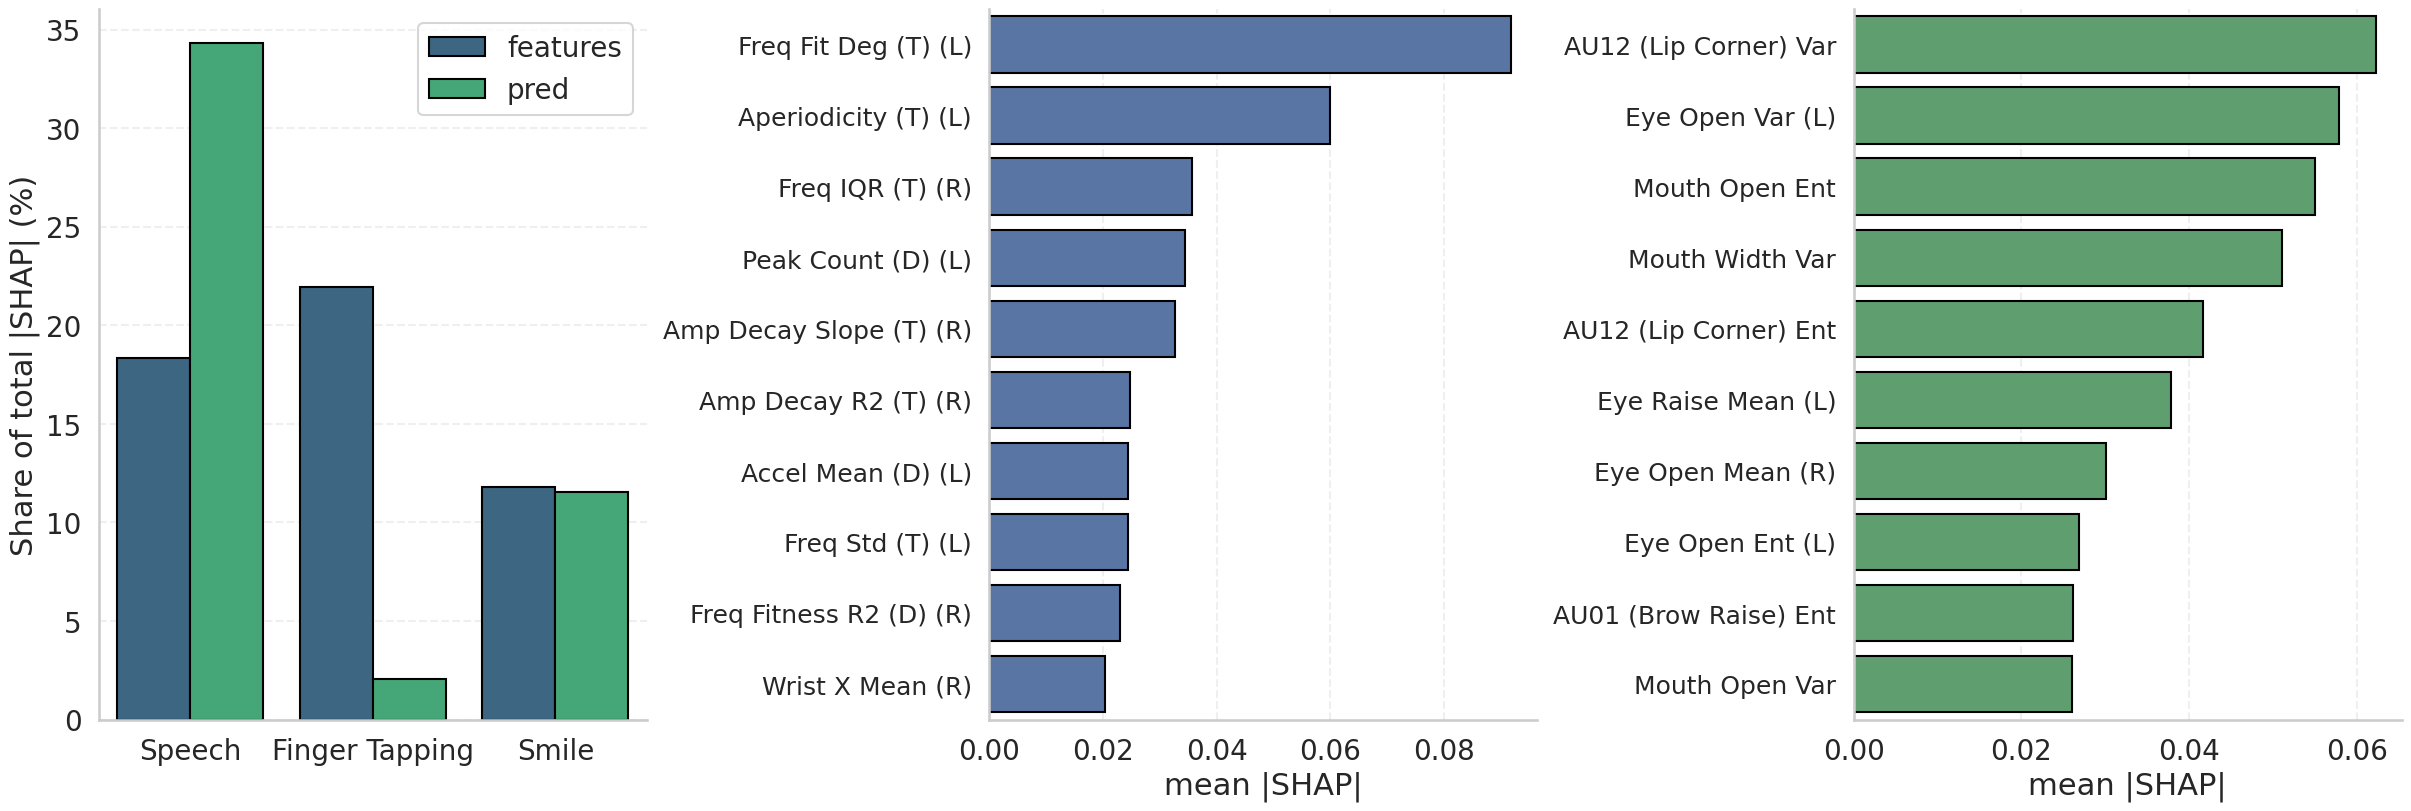

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ===================== SHAP – Combined 3-Panel Figure =====================

# --- Inputs assumed present from your pipeline ---
# shap_vals_test, mean_abs_t, modality_names, feat_slices, mod_totals_test, etc.

# ---------------- helpers ----------------
def topk_features_for_mod_test(mod_name: str, k: int = 10):
    """Return top-k feature rows."""
    if mod_name not in modality_names:
        return pd.DataFrame(columns=["feature", "mean_abs_shap"])

    i = modality_names.index(mod_name)
    sl  = feat_slices[i]
    vals = mean_abs_t[sl]
    order = np.argsort(vals)[::-1][:k]
    raw_names = [f"{mod_name}_{j}" for j in order]
    
    if "feature_maps" in globals() and isinstance(feature_maps, dict) and mod_name in feature_maps:
        fmap = feature_maps[mod_name]
        names = [fmap.get(n, n) for n in raw_names]
    else:
        names = raw_names
    return pd.DataFrame({"feature": names, "mean_abs_shap": vals[order]})

# ... (previous import and helper code) ...

# ---------------- data preparation ----------------
# 1. Panel A Data: Modality Contribution
comp = mod_totals_test.melt(id_vars=["modality"],
                            value_vars=["features_sum","pred"], 
                            var_name="component", value_name="value")

comp["component"] = comp["component"].replace({
    "features_sum": "features", 
    "pred": "pred"
})

comp["percent_global"] = 100 * comp["value"] / comp["value"].sum()

# --- NEW: RENAME MODALITIES HERE ---
# Define the mapping from old names to new names
rename_map = {
    "speech": "Speech",
    "finger": "Finger Tapping",
    "smile":  "Smile"
}

# Apply the renaming to the dataframe
comp["modality"] = comp["modality"].replace(rename_map)

# Update the order list to match the NEW names
mod_order = ["Speech", "Finger Tapping", "Smile"] 
# -----------------------------------

# 2. Top-k Data for features (Code remains the same, internal lookups use old names)
TOPK = 10
df_finger = topk_features_for_mod_test("finger", TOPK).sort_values("mean_abs_shap", ascending=False)
df_smile  = topk_features_for_mod_test("smile",  TOPK).sort_values("mean_abs_shap", ascending=False)

# ---------------- styling ----------------
sns.set_theme(context="talk", style="whitegrid")
plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 24
})

OUT_DIR = os.path.join("shap_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- PLOTTING ONE ROW ----------------
fig, axs = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

# --- Panel 1: Modality Contribution ---
sns.barplot(
    data=comp, x="modality", y="percent_global", hue="component",
    order=mod_order,  # Uses the new capitalized names
    edgecolor="black",
    palette="viridis",
    ax=axs[0]
)
axs[0].set_ylabel("Share of total |SHAP| (%)")
axs[0].set_xlabel("") 
axs[0].legend(title="", loc="upper right", frameon=True)
axs[0].grid(axis="y", linestyle="--", alpha=0.3)
axs[0].tick_params(axis='x', labelsize=20) # Font size for "Speech", "Finger Tapping", "Smile"

# ... (Rest of the plotting code for Panel 2 and 3 remains the same)
# --- Panel 2: Finger Tapping Features ---
if not df_finger.empty:
    sns.barplot(
        data=df_finger,
        x="mean_abs_shap", y="feature",
        edgecolor="black", color="C0",
        ax=axs[1]
    )
    # axs[1].set_title("b. Finger Tapping Features")
    axs[1].set_xlabel("mean |SHAP|")
    axs[1].set_ylabel("")
    # Force y-tick labels (feature names) to be consistent size
    axs[1].tick_params(axis='y', labelsize=18) 
    axs[1].grid(axis="x", linestyle="--", alpha=0.3)

# --- Panel 3: Smile Features ---
if not df_smile.empty:
    sns.barplot(
        data=df_smile,
        x="mean_abs_shap", y="feature",
        edgecolor="black", color="C2",
        ax=axs[2]
    )
    # axs[2].set_title("c. Smile Features")
    axs[2].set_xlabel("mean |SHAP|")
    axs[2].set_ylabel("")
    # Force y-tick labels to match the finger plot size
    axs[2].tick_params(axis='y', labelsize=18) 
    axs[2].grid(axis="x", linestyle="--", alpha=0.3)

# Common clean-up
for ax in axs:
    sns.despine(ax=ax, top=True, right=True)

# Save
save_name = "shap_combined_row_UFNet_full_data"
png_path = os.path.join(OUT_DIR, f"{save_name}.png")

plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"[INFO] Saved combined figure to: {png_path}")
plt.show()